In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

In [72]:
iris = load_iris()

In [73]:
X = iris.data[:,2:]
y = iris.target

In [74]:
print(X.shape)

(150, 2)


In [76]:
#creating the random Forest

rf = RandomForestClassifier(
    n_estimators=500,
    max_leaf_nodes=16,
    n_jobs=-1,
    random_state=42
)

rf.fit(X,y)

RandomForestClassifier(max_leaf_nodes=16, n_estimators=500, n_jobs=-1,
                       random_state=42)

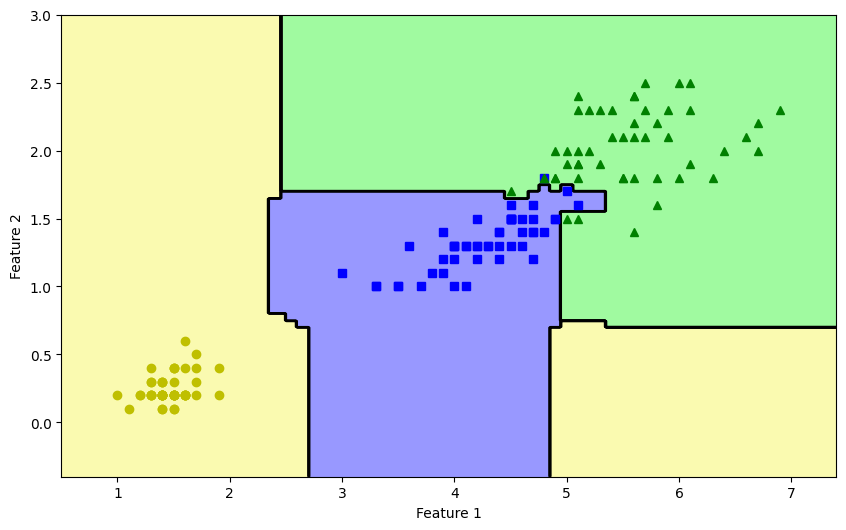

In [77]:
from matplotlib.colors import ListedColormap

def plot_boundries_dec_tree_class(model, x, y):
    x0_min, x0_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
    x1_min, x1_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5

    xx0, xx1 = np.meshgrid(
        np.linspace(x0_min, x0_max, 500),
        np.linspace(x1_min, x1_max, 500)
    )

    y_pred = model.predict(np.c_[xx0.ravel(), xx1.ravel()]).reshape(xx0.shape)

    custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.contourf(xx0, xx1, y_pred, cmap=custom_cmap)
    ax.contour(xx0, xx1, y_pred, colors="black", linewidths=1.5)

    ax.plot(x[:, 0][y==0], x[:, 1][y==0], "yo", markersize=6)
    ax.plot(x[:, 0][y==1], x[:, 1][y==1], "bs", markersize=6)
    ax.plot(x[:, 0][y==2], x[:, 1][y==2], "g^", markersize=6)

    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_xlim(x0_min, x0_max)
    ax.set_ylim(x1_min, x1_max)

plot_boundries_dec_tree_class(rf,X,y)

